In [1]:
# Parameters
system_name = "J1515+1511"
filter = "F160W"
use_psf_variance_map = True
r1 = 3.7
dx_outer = -0.3
dy_outer = 0.6
dx_center = 0.0
dy_center = 0.1
x1 = 41
y1 = 59
x2 = 56
y2 = 45
x3 = 63
y3 = 45
use_center_mask = False
r1_f814w = 2.2
dx_outer_f814w = -0.5
dy_outer_f814w = 0.3
lens_center_x_f814w = 110
lens_center_y_f814w = 89
r1_f475x = 2.2
dx_outer_f475x = -0.5
dy_outer_f475x = 0.3
lens_center_x_f475x = 110
lens_center_y_f475x = 89


In [2]:
# import the necessary python modules
import numpy as np
import time
import corner
from astropy.cosmology import FlatLambdaCDM

import lenstronomy

from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.Cosmo.lens_cosmo import LensCosmo
from lenstronomy.Util import constants
from lenstronomy.Util import param_util
from lenstronomy.Plots import lens_plot

import matplotlib.pyplot as plt
%matplotlib inline

import pickle

Notebook inspired by: https://github.com/lenstronomy/lenstronomy-tutorials/blob/main/Notebooks/LensModeling/modelling_of_catalogue_data.ipynb

In [3]:
# Load model data

filename = f"joint_modeling/{system_name}/{system_name}_joint.pkl"

with open(filename, "rb") as f:
    loaded_data = pickle.load(f)

kwargs_result = loaded_data["kwargs_result"]

ra_lens = kwargs_result['kwargs_lens'][0]['center_x']
dec_lens = kwargs_result['kwargs_lens'][0]['center_y']

ra_im1 = kwargs_result['kwargs_ps'][0]['ra_image'][0] - ra_lens
dec_im1 = kwargs_result['kwargs_ps'][0]['dec_image'][0] - dec_lens

ra_im2 = kwargs_result['kwargs_ps'][0]['ra_image'][1] - ra_lens
dec_im2 = kwargs_result['kwargs_ps'][0]['dec_image'][1] - dec_lens

image_sep = np.sqrt((ra_im1 - ra_im2)**2 + (dec_im1 - dec_im2)**2)

ximg = np.array([ra_im1, ra_im2])
yimg = np.array([dec_im1, dec_im2])

In [4]:
# ==================
# lens model choices
# ==================
lens_model_list = ['EPL', 'SHEAR']

fixed_lens = []
kwargs_lens_init = []
kwargs_lens_sigma = []
kwargs_lower_lens = []
kwargs_upper_lens = []

# SIE
fixed_lens.append({'gamma': 2, 'center_x': 0.0, 'center_y': 0.0})

kwargs_lens_init.append({
    'theta_E': image_sep/2,   
    'gamma': 2,
    'center_x': 0.0,
    'center_y': 0.0,
    'e1': 0.0,
    'e2': 0.0
})

kwargs_lens_sigma.append({'theta_E': .1, 'e1': 0.1, 'e2': 0.1})
kwargs_lower_lens.append({'theta_E': 0.01, 'e1': -0.5, 'e2': -0.5})
kwargs_upper_lens.append({'theta_E': 5., 'e1': 0.5, 'e2': 0.5})

# Shear
fixed_lens.append({'ra_0': 0, 'dec_0': 0})
kwargs_lens_init.append({'gamma1': 0., 'gamma2': 0.})
kwargs_lens_sigma.append({'gamma1': 0.1, 'gamma2': 0.1})
kwargs_lower_lens.append({'gamma1': -0.106, 'gamma2': -0.106})
kwargs_upper_lens.append({'gamma1': 0.106, 'gamma2': 0.106})

lens_params = [kwargs_lens_init, kwargs_lens_sigma, fixed_lens,
               kwargs_lower_lens, kwargs_upper_lens]

# =========================
# image position parameters
# =========================

point_source_list = ['LENSED_POSITION']

kwargs_ps_init = [{'ra_image': ximg, 'dec_image': yimg}]
fixed_ps = [{}]
kwargs_ps_sigma = [{'ra_image': [0.02] * 2, 'dec_image': [0.02] * 2}]
kwargs_lower_ps = [{'ra_image': -5 * np.ones_like(ximg), 'dec_image': -5 * np.ones_like(yimg)}]
kwargs_upper_ps = [{'ra_image': 5 * np.ones_like(ximg), 'dec_image': 5 * np.ones_like(yimg)}]

# combine all parameter options for lenstronomy
ps_params = [kwargs_ps_init, kwargs_ps_sigma, fixed_ps, kwargs_lower_ps, kwargs_upper_ps]

# ==================
# combined params
# ==================

kwargs_params = {
    'lens_model': lens_params,
    'point_source_model': ps_params
}

# ==================
# Model choices
# ==================
kwargs_model = {
    'lens_model_list': lens_model_list,
    'point_source_model_list': point_source_list
}

# ==================
# Imaging data
# ==================
kwargs_data_joint = {'ra_image_list': [ximg], 'dec_image_list': [yimg]}

astrometry_sigma = 0.005

# ==================
# Likelihood
# ==================
kwargs_likelihood = {
    'image_position_uncertainty': astrometry_sigma,
    'image_position_likelihood': True,
    'flux_ratio_likelihood': False,
    'check_bounds': True,
    'source_position_likelihood': True,
    'source_position_tolerance': 0.01
}

kwargs_constraints = {
    'num_point_source_list': [2],
    'solver_type': 'NONE'
}


In [5]:
from lenstronomy.Workflow.fitting_sequence import FittingSequence
fitting_seq = FittingSequence(kwargs_data_joint, kwargs_model, kwargs_constraints, kwargs_likelihood, kwargs_params)

fitting_kwargs_list = [
                       ['PSO', {'sigma_scale': 1., 'n_particles': 200, 'n_iterations': 500}]
                    ]

start_time = time.time()
chain_list_pso = fitting_seq.fit_sequence(fitting_kwargs_list)
kwargs_result = fitting_seq.best_fit()
end_time = time.time()
print(end_time - start_time, 'total time needed for computation')
print('============ CONGRATULATION, YOUR JOB WAS SUCCESSFUL ================ ')

Computing the PSO ...


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 1/500 [00:00<01:25,  5.82it/s]

  1%|          | 3/500 [00:00<00:53,  9.29it/s]

  1%|          | 5/500 [00:00<00:47, 10.43it/s]

...

 23%|██▎       | 113/500 [00:09<00:33, 11.56it/s]

 23%|██▎       | 115/500 [00:10<00:33, 11.56it/s]

 23%|██▎       | 117/500 [00:10<00:33, 11.56it/s]

 23%|██▎       | 117/500 [00:10<00:33, 11.49it/s]

Converged after 117 iterations!
Best fit found:  -4.520536131632532e-05 [1.0066321511564595, -0.00657485127436773, 0.05947752660508012, -0.006916748386471194, 0.020940262353215375, -1.1776586891017724, 0.49078842184910976, 0.8074598918031216, -0.30445154116143075]
-9.041072263265064e-05 reduced X^2 of best position
-4.520536131632532e-05 log likelihood
-5 effective number of data points
[{'theta_E': 1.0066321511564595, 'gamma': 2, 'e1': -0.00657485127436773, 'e2': 0.05947752660508012, 'center_x': 0.0, 'center_y': 0.0}, {'gamma1': -0.006916748386471194, 'gamma2': 0.020940262353215375, 'ra_0': 0, 'dec_0': 0}] lens result
[] source result
[] lens light result
[{'ra_image': array([-1.17765869,  0.49078842]), 'dec_image': array([ 0.80745989, -0.30445154]), 'point_amp': array([1., 1.])}] point source result
[] tracer source result
{} special param result
10.185296058654785 time used for  PSO
10.586254119873047 total time needed for computation
============ CONGRATULATION, YOUR JOB WAS SUCCES

Prior likelihood = 0
source position likelihood -8.74652819411079e-06
image position likelihood -3.645883312221453e-05


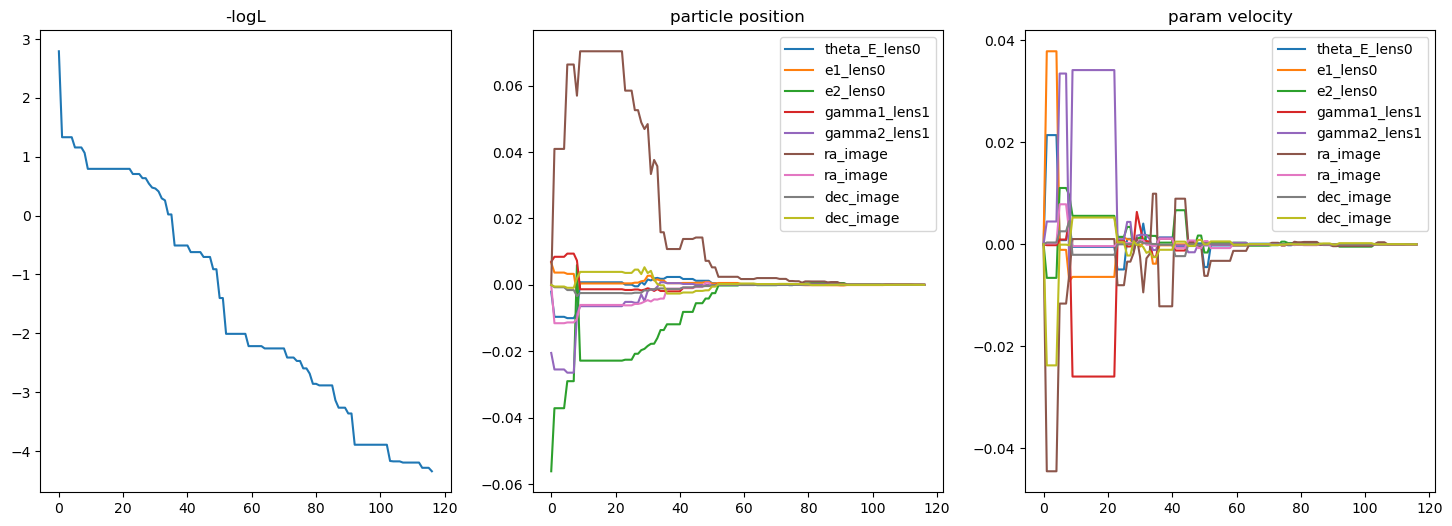

<Figure size 640x480 with 0 Axes>

In [6]:
kwargs_result = fitting_seq.best_fit(bijective=True)
args_result = fitting_seq.param_class.kwargs2args(**kwargs_result)
logL = fitting_seq.likelihoodModule.logL(args_result, verbose=True)

from lenstronomy.Plots import chain_plot
for i in range(len(chain_list_pso)):
    chain_plot.plot_chain_list(chain_list_pso, i)

plt.show()

In [7]:
#and now we run the MCMC
fitting_kwargs_list = [
    ['MCMC', {'n_burn': 500, 'n_run': 1500, 'walkerRatio': 10,'sigma_scale': 0.1}]
]
chain_list_mcmc = fitting_seq.fit_sequence(fitting_kwargs_list)
kwargs_result = fitting_seq.best_fit()

MCMC selected. Sampling with default option emcee.


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 3/2000 [00:00<01:16, 26.04it/s]

  0%|          | 6/2000 [00:00<01:16, 26.10it/s]

  0%|          | 9/2000 [00:00<01:15, 26.21it/s]

...

100%|█████████▉| 1992/2000 [01:00<00:00, 36.11it/s]

100%|█████████▉| 1996/2000 [01:00<00:00, 35.89it/s]

100%|██████████| 2000/2000 [01:00<00:00, 35.66it/s]

100%|██████████| 2000/2000 [01:00<00:00, 33.03it/s]

Computing the MCMC...
Number of walkers =  90
Burn-in iterations:  500
Sampling iterations (in current run): 2000
60.599321365356445 time taken for MCMC sampling


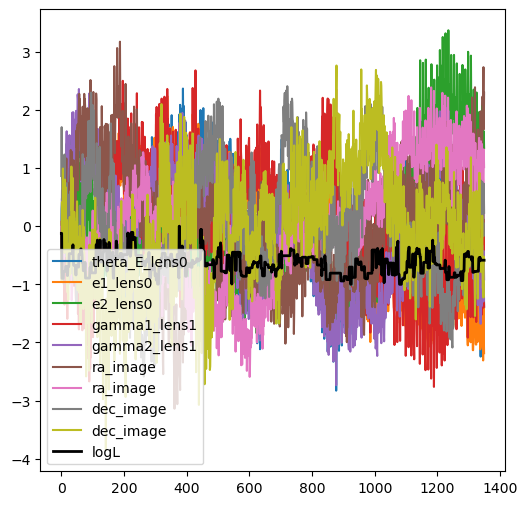

In [8]:
chain_plot.plot_chain_list(chain_list_mcmc)
plt.show()

In [9]:
sampler_type, samples_mcmc, param_mcmc, dist_mcmc  = chain_list_mcmc[0]

print("number of non-linear parameters in the MCMC process: ", len(param_mcmc))
print("parameters in order: ", param_mcmc)
print("number of evaluations in the MCMC process: ", np.shape(samples_mcmc)[0])

# import the parameter handling class #
from lenstronomy.Sampling.parameters import Param
import lenstronomy.Util.param_util as param_util
# make instance of parameter class with given model options, constraints and fixed parameters
# this allows to recover the full parameters of all model components, not just the ones being sampled.

param = Param(kwargs_model, fixed_lens, kwargs_fixed_ps=fixed_ps,
              kwargs_lens_init=kwargs_result['kwargs_lens'], **kwargs_constraints)
# the number of non-linear parameters and their names #
num_param, param_list = param.num_param()


lensModel = LensModel(kwargs_model['lens_model_list'])
lensModelExtensions = LensModelExtensions(lensModel=lensModel) 

mcmc_new_list = []
labels_new = [r"$\theta_E$", r"$\phi_{lens}$", r"$q$", r"$\phi_{ext}$", r"$\gamma_{ext}$"]

    
print(labels_new)

number of non-linear parameters in the MCMC process:  9
parameters in order:  ['theta_E_lens0', 'e1_lens0', 'e2_lens0', 'gamma1_lens1', 'gamma2_lens1', 'ra_image', 'ra_image', 'dec_image', 'dec_image']
number of evaluations in the MCMC process:  135000
['$\\theta_E$', '$\\phi_{lens}$', '$q$', '$\\phi_{ext}$', '$\\gamma_{ext}$']


In [10]:
for i in range(len(samples_mcmc)):
    # transform the parameter position of the MCMC chain in a lenstronomy convention with keyword arguments #
    kwargs_out = param.args2kwargs(samples_mcmc[i])
    kwargs_lens_out = kwargs_out['kwargs_lens']
    
    # extract quantities of the main deflector
    theta_E = kwargs_lens_out[0]['theta_E']
    e1, e2 = kwargs_lens_out[0]['e1'], kwargs_lens_out[0]['e2']
    phi, q = param_util.ellipticity2phi_q(e1, e2)
    gamma1, gamma2 = kwargs_lens_out[1]['gamma1'], kwargs_lens_out[1]['gamma2']
    phi_ext, gamma_ext = param_util.shear_cartesian2polar(gamma1, gamma2)
    new_chain = [theta_E, phi, q, phi_ext, gamma_ext]
    
    mcmc_new_list.append(np.array(new_chain))

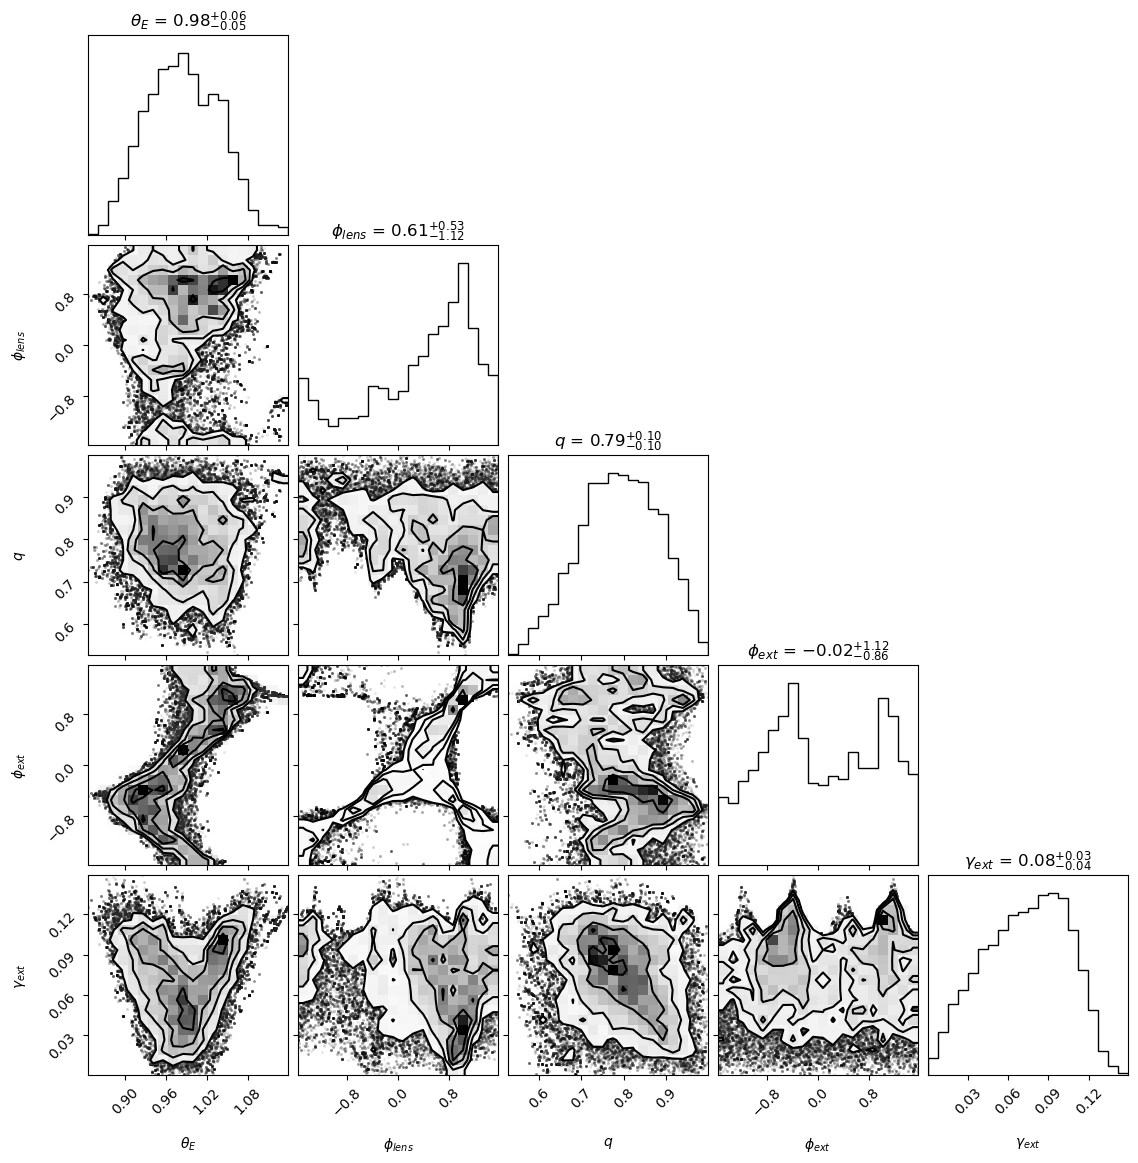

In [11]:
plot = corner.corner(np.array(mcmc_new_list), labels=labels_new, show_titles=True)
plt.show()

In [12]:
output_file = f"conjugate_point/{system_name}/{system_name}_conjugate.pkl"

# package results in a dictionary
results_dict = {
    "kwargs_result": kwargs_result,
    "kwargs_model": kwargs_model,
    "samples_raw": samples_mcmc,
    "kwargs_constraints": kwargs_constraints,
    "chain_list": chain_list_mcmc,
    "processed_chain": np.array(mcmc_new_list),
    "labels": labels_new,
    "param_list": param_mcmc          
}

# save
with open(output_file, "wb") as f:
    pickle.dump(results_dict, f)

print(f"MCMC results saved to {output_file}")

MCMC results saved to conjugate_point/J1515+1511/J1515+1511_conjugate.pkl
